In [56]:
# Q1 Import Libraries

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [58]:
# Q2 Load Dataset

In [59]:
train_df=pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
test_df= pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

In [60]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [61]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [62]:
# Q3 Check Missing Values

In [63]:
train_df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [64]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


Both Dataset Were loaded to understand datatype, missing values.

In [65]:
#Q4 Handle Missing Values in  LoanAmount (Median)

In [66]:
loan_median= train_df.groupby("Property_Area")["LoanAmount"].median()


In [67]:
loan_median

,LoanAmount
Property_Area,
Rural,133.0
Semiurban,127.5
Urban,120.0


In [68]:
# Fill missing values using group median

train_df['LoanAmount'] = train_df['LoanAmount'].fillna(train_df.groupby('Property_Area')['LoanAmount'].transform('median'))

In [69]:
train_df['LoanAmount']

,LoanAmount
0,120.0
1,128.0
2,66.0
3,120.0
4,141.0
...,...
609,71.0
610,40.0
611,253.0
612,187.0


In [70]:
# Apply same logic to test dataset

In [71]:
test_df['LoanAmount'] = test_df['LoanAmount'].fillna(
    test_df.groupby('Property_Area')['LoanAmount'].transform('median')
)


In [72]:
test_df['LoanAmount']

,LoanAmount
0,110.0
1,126.0
2,208.0
3,100.0
4,78.0
...,...
362,113.0
363,115.0
364,126.0
365,158.0


In [73]:
# Why Median? Median is robust to outliers and skewed distributions.

In [74]:
# Q5 Outliers in Incomes (IQR Method)

In [75]:
Q1 = train_df['ApplicantIncome'].quantile(0.25)
Q3 = train_df['ApplicantIncome'].quantile(0.75)
IQR= Q3 - Q1

Lower_Bound = Q1-1.5 * IQR
Upper_Bound = Q3+1.5 * IQR

In [76]:

Lower_Bound = Q1-1.5 * IQR
Upper_Bound = Q3+1.5 * IQR

In [77]:

Lower_Bound


np.float64(-1498.75)

In [78]:
Upper_Bound

np.float64(10171.25)

In [79]:
 #Q6 Remove Outliers from Test Data (Using  IQR)

In [80]:
test_df = test_df[
    (test_df['ApplicantIncome'] >= Lower_Bound) &
    (test_df['ApplicantIncome'] <= Upper_Bound)
]


In [81]:
#same  logic for Test datset

In [82]:
Q1 = test_df['ApplicantIncome'].quantile(0.25)
Q3 = test_df['ApplicantIncome'].quantile(0.75)
IQR= Q3 - Q1

Lower_Bound = Q1-1.5 * IQR
Upper_Bound = Q3+1.5 * IQR

In [83]:
Lower_Bound

np.float64(-356.5)

In [84]:
Upper_Bound

np.float64(8027.5)

In [85]:
# Q7 Average Loan Amount by Gender and  Property Areafor Credit History = 1.0

In [86]:
avg_loan = (
    test_df[test_df['Credit_History'] == 1.0]
    .groupby(['Gender', 'Property_Area'])['LoanAmount']
    .mean()
    .reset_index()
)


In [87]:
avg_loan =(
    test_df[test_df['Credit_History']==1.0].groupby(['Gender','Property_Area'])['LoanAmount'].mean().reset_index()


           )

In [88]:
avg_loan

,Gender,Property_Area,LoanAmount
0,Female,Rural,131.833333
1,Female,Semiurban,116.200000
2,Female,Urban,129.176471
3,Male,Rural,135.777778
4,Male,Semiurban,133.175439
5,Male,Urban,135.855556


# Insight:
Applicants with valid credit history tend to qualifyfor higher loan amounts.

In [89]:
# Q8 Boxplot of  Applicant Income by Education


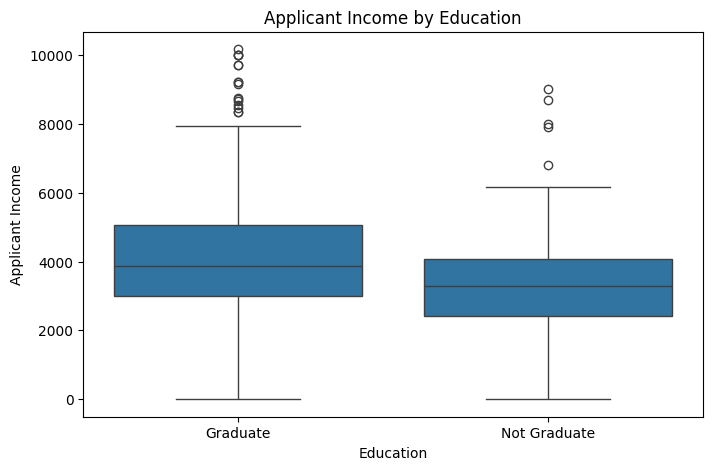

In [90]:


plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='ApplicantIncome', data=test_df)
plt.title('Applicant Income by Education')
plt.xlabel('Education')
plt.ylabel('Applicant Income')
plt.show()


#Insights
Graduates typically earn a higher median income than non-graduates, showing that education influences earning potential.

In [91]:
# Q9 Correlation Heatmap for numeric feature

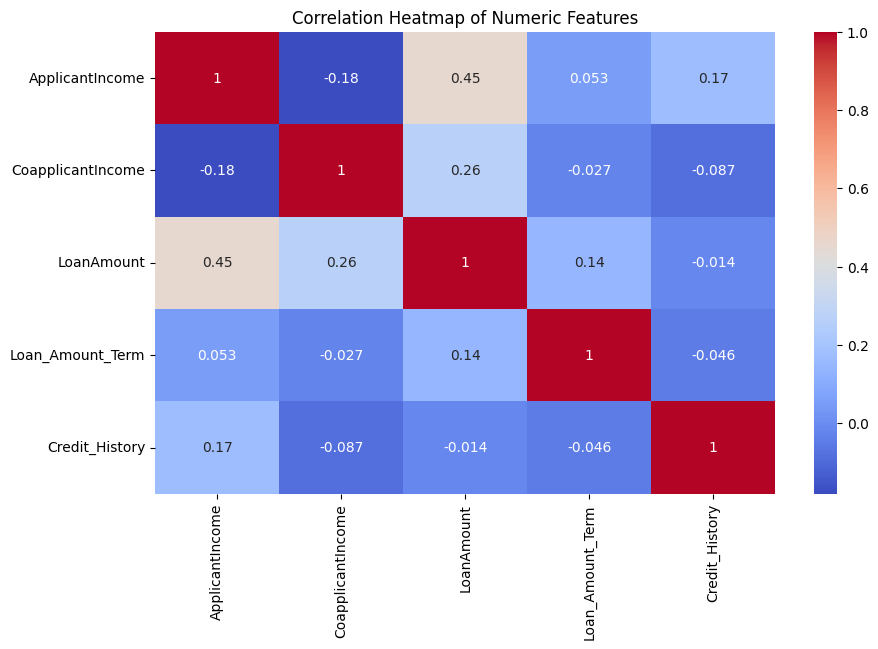

In [92]:
plt.figure(figsize=(10,6))
sns.heatmap(test_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



#Insights
 - LoanAmount shows a positive correlation with ApplicantIncome, indicating  higher-income applicants tend to request larger loan amounts.
- DTI is positively correlated with LoanAmount and negatively correlated with ApplicantIncome, confirming that higher loans relative to income increase repayment burden.
- Credit history doesn’t strongly relate to income or loan amount, meaning it’s judged mostly on its own.

Calculate Debt to income ratio(DTI)

In [93]:
test_df["DTI"] = test_df["LoanAmount"] / test_df["ApplicantIncome"]


In [94]:
test_df["DTI"]

,DTI
0,0.019231
1,0.040962
2,0.041600
3,0.042735
4,0.023810
...,...
362,0.028187
363,0.027658
364,0.038769
365,0.031600


In [95]:
income_median = train_df["ApplicantIncome"].median()

In [96]:
income_median

3812.5

In [97]:
# Q11 Identify High-Risk Segments

In [98]:


high_risk = test_df[
    (test_df["Property_Area"] == "Rural") &
    (test_df["ApplicantIncome"] < income_median) &
    (test_df["DTI"] > 0.40)]





In [99]:

high_risk

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,DTI
25,LP001153,Male,No,0,Graduate,No,0,24000,148.0,360.0,0.0,Rural,inf


#Insights
- Applicants from rural areas with lower income levels and higher
debt-to-income ratios represent a higher credit risk. A DTI above 40%
- indicates increased repayment burden, particularly for applicants with
limited income capacity.


#Conclusion
- The analysis shows that credit history is the main factor for loan approval.
- People with low income and high loan amounts are more risky. Cleaning the data helped make the results more accurate.